In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  

Сводные таблицы и таблицы сопряженности


В датафрейме ниже представлены результаты соревнований по электронным играм: для каждого игрока указана игра и набранное количество очков в нескольких попытках.

data = {

    'Name': ['Анна', 'Антон', 'Мария', 'Макс', 'Макс', 'Алекс', 'Антон', 'Мария', 'Макс', 'Алекс', 'Антон', 'Анна'],

  'Game': ['тетрис', 'змейка', 'змейка', 'тетрис', 'тетрис', 'змейка', 'тетрис', 'тетрис', 'тетрис', 'змейка', 'змейка', 'тетрис'],

    'Points': [145, 2524, 343, 4212, 5212, 6421, 745, 842, 524, 3224, 212, 1214]      

}

Вам нужно узнать среднее количество очков каждого игрока по каждой игре. Используйте сводные таблицы или таблицы сопряженности.

In [3]:
data = {
    'Name': ['Анна', 'Антон', 'Мария', 'Макс', 'Макс', 'Алекс', 'Антон', 'Мария', 'Макс', 'Алекс', 'Антон', 'Анна'],
    'Game': ['тетрис', 'змейка', 'змейка', 'тетрис', 'тетрис', 'змейка', 'тетрис', 'тетрис', 'тетрис', 'змейка', 'змейка', 'тетрис'],
    'Points': [145, 2524, 343, 4212, 5212, 6421, 745, 842, 524, 3224, 212, 1214]      
}
df = pd.DataFrame(data)
display(df)
display(pd.pivot_table(df, index='Name', columns='Game', values='Points', aggfunc='mean', fill_value=0))



,Name,Game,Points
0,Анна,тетрис,145
1,Антон,змейка,2524
2,Мария,змейка,343
3,Макс,тетрис,4212
4,Макс,тетрис,5212
5,Алекс,змейка,6421
6,Антон,тетрис,745
7,Мария,тетрис,842
8,Макс,тетрис,524
9,Алекс,змейка,3224


Game,змейка,тетрис
Name,,
Алекс,4822.5,0.0
Анна,0.0,679.5
Антон,1368.0,745.0
Макс,0.0,3316.0
Мария,343.0,842.0


Построение диаграмм


Напишите программу для анализа данных по потреблению электроэнергии в 25-квартирном доме в текущем месяце. Нужно:

Сгенерировать случайные данные о потреблении каждой квартиры – от 100 до 1000 кВт.

Визуализировать на круговой диаграмме энергопотребление каждой квартиры.

Представить ту же информацию в виде столбчатой диаграммы.

,Date,Flat,Energy Consumption
0,2026-04-01,Flat № 1,12
1,2026-04-02,Flat № 1,16
2,2026-04-03,Flat № 1,2
3,2026-04-04,Flat № 1,14
4,2026-04-05,Flat № 1,19
...,...,...,...
745,2026-04-26,Flat № 25,19
746,2026-04-27,Flat № 25,6
747,2026-04-28,Flat № 25,1
748,2026-04-29,Flat № 25,1


,Flat,Energy Consumption
0,Flat № 1,317
1,Flat № 10,345
2,Flat № 11,300
3,Flat № 12,327
4,Flat № 13,251
5,Flat № 14,274
6,Flat № 15,285
7,Flat № 16,285
8,Flat № 17,295
9,Flat № 18,295


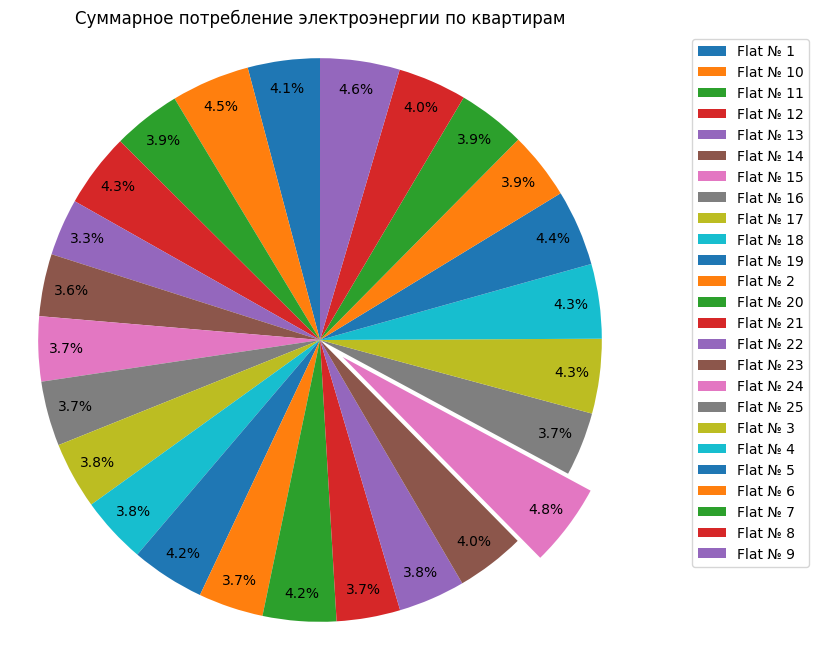

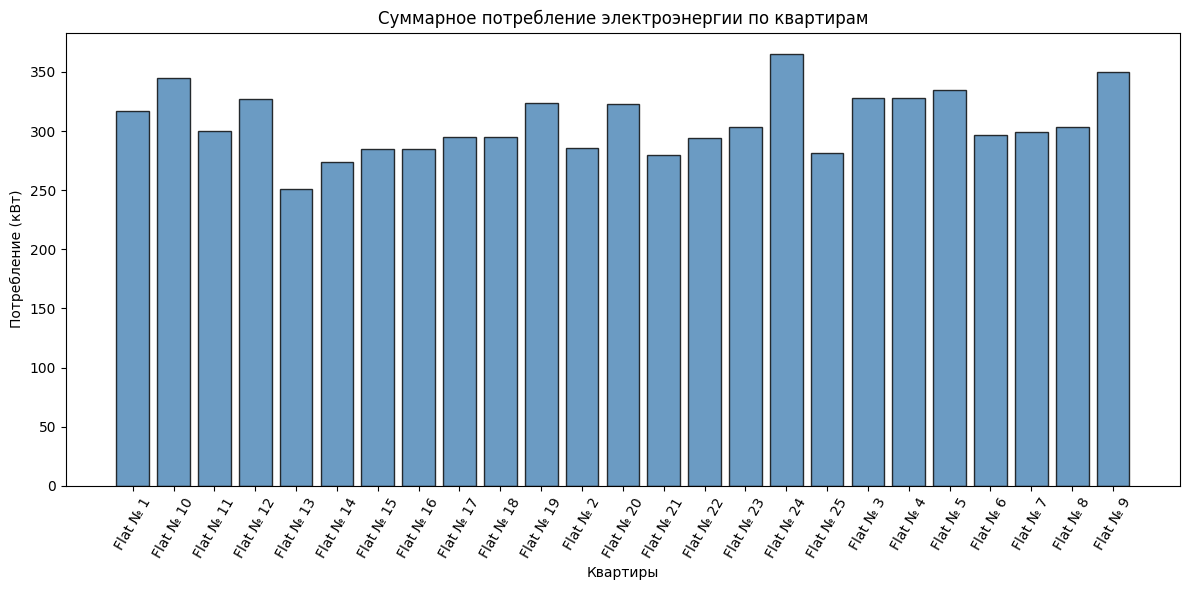

In [42]:
n_flats = 25
n_days = 30

dates = pd.date_range(start='2026-04-01', periods=n_days, freq='D')

df_energy = pd.DataFrame({
    'Date': np.tile(dates, n_flats),
    'Flat': np.repeat([f'Flat № {i+1}' for i in range(n_flats)], n_days),
    'Energy Consumption': np.random.randint(1, 21, size=n_flats * n_days)
})

display(df_energy)


flat_totals = df_energy.groupby('Flat', as_index=False)['Energy Consumption'].sum()
display(flat_totals)


labels = flat_totals['Flat']
sizes = flat_totals['Energy Consumption']
explode = [0.1 if value == sizes.max() else 0 for value in sizes]

plt.figure(figsize=(8,8))
plt.pie(
    sizes,
    explode=explode,
    pctdistance=0.9,
    autopct='%1.1f%%',
    startangle=90
 )
plt.title('Суммарное потребление электроэнергии по квартирам')
plt.axis('equal')
plt.legend(labels, loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()


plt.figure(figsize=(12, 6))
plt.bar(labels, sizes, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Суммарное потребление электроэнергии по квартирам')
plt.xlabel('Квартиры')
plt.ylabel('Потребление (кВт)')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()